### testing the KC1 classification

In [11]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, log_loss
# Generate dummy data
with np.load("..\data\kc1\kc1.npz", allow_pickle=True) as file:
    x = file["x"].astype(np.float32)
    y = file["y"].reshape(-1, 1).astype(np.int32)
# Create a simple model
model = Sequential()
model.add(Dense(64, input_dim=x.shape[-1], activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Split the dataset into train and test
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Fit the model on the training data
model.fit(x_train, y_train, epochs=10, batch_size=32)

# Predict on the test data
y_pred = model.predict(x_test)
y_pred_classes = (y_pred > 0.5).astype("int32")

# Calculate accuracy and log loss
accuracy = accuracy_score(y_test, y_pred_classes)

print(f"Test Accuracy: {accuracy}")



Epoch 1/10
53/53 [==============================] - 1s 2ms/step - loss: 0.5512 - accuracy: 0.9502
Epoch 2/10
53/53 [==============================] - 0s 2ms/step - loss: 0.2719 - accuracy: 1.0000
Epoch 3/10
53/53 [==============================] - 0s 2ms/step - loss: 0.1141 - accuracy: 1.0000
Epoch 4/10
53/53 [==============================] - 0s 2ms/step - loss: 0.0557 - accuracy: 1.0000
Epoch 5/10
53/53 [==============================] - 0s 2ms/step - loss: 0.0323 - accuracy: 1.0000
Epoch 6/10
53/53 [==============================] - 0s 2ms/step - loss: 0.0210 - accuracy: 1.0000
Epoch 7/10
53/53 [==============================] - 0s 2ms/step - loss: 0.0148 - accuracy: 1.0000
Epoch 8/10
53/53 [==============================] - 0s 2ms/step - loss: 0.0110 - accuracy: 1.0000
Epoch 9/10
53/53 [==============================] - 0s 2ms/step - loss: 0.0085 - accuracy: 1.0000
Epoch 10/10
14/14 [==============================] - 0s 1ms/step
Test Accuracy: 1.0


In [12]:
x.shape

(2109, 21)

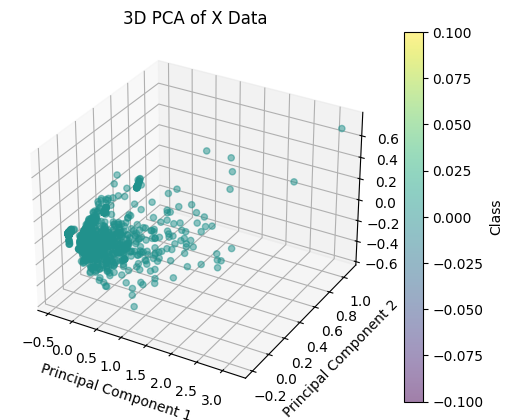

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA to reduce the dimensions to 3
pca = PCA(n_components=3)
x_pca = pca.fit_transform(x)

# Plot the 3D PCA result with color coding based on class
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(x_pca[:, 0], x_pca[:, 1], x_pca[:, 2], c=y.flatten(), cmap='viridis', marker='o', alpha=0.5)
ax.set_title('3D PCA of X Data')
ax.set_xlabel('Principal Component 1')
ax.set_ylabel('Principal Component 2')
ax.set_zlabel('Principal Component 3')

# Add a color bar
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Class')

plt.show()

In [18]:
np.unique(y)

array([0])